# Logistic Regression from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

Logistic Regression is a binary classification algorithm that models the probability of class membership using the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = X\theta + b$. The model is trained using **gradient descent** to minimize binary cross-entropy loss:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.logistic_regression import LogisticRegression
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Breast Cancer Wisconsin dataset** — 569 samples, 30 features, binary target (malignant vs benign). This is a classic binary classification benchmark.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: [212 357]


## Preprocessing and Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 455
Test samples: 114


## Training the Model

In [5]:
model = LogisticRegression(learning_rate=0.1, max_iter=1000)
print("Training Logistic Regression...")
model.fit(X_train_scaled, y_train)
print("Training Complete.")

Training Logistic Regression...
Training Complete.


## Evaluation

In [7]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

Accuracy: 0.9825

Confusion Matrix:
[[42  1]
 [ 1 70]]


## Visualizing the Confusion Matrix

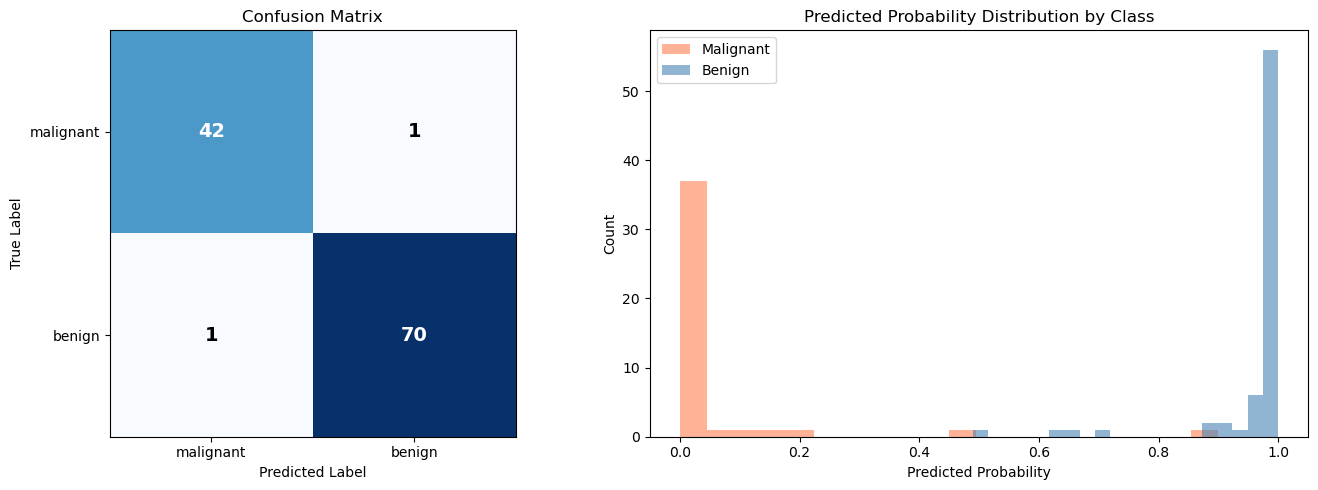

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
im = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(data.target_names)
axes[0].set_yticklabels(data.target_names)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center',
                     va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Predicted probabilities
axes[1].hist(y_proba[y_test == 0], bins=20, alpha=0.6,
             color='coral', label='Malignant')
axes[1].hist(y_proba[y_test == 1], bins=20, alpha=0.6,
             color='steelblue', label='Benign')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()## Discussion

## Discussion

- The model achieves **98.2% accuracy** (112/114 correct) on the breast cancer dataset, which is exceptional performance for a from-scratch implementation
- The confusion matrix shows only **2 misclassifications**: 1 false positive and 1 false negative out of 114 test samples
- The probability distribution shows near-perfect separation. Malignant predictions cluster near 0 and benign near 1, meaning the model is highly confident
- Feature scaling was critical, because without StandardScaler, gradient descent would converge much more slowly or not at all
- Logistic regression works exceptionally well here because the breast cancer dataset is largely linearly separable in the 30-feature space